# Final Project - STA4724

### How well can a set of water quality predictors predict changes in dissolved oxygen levels for the Back Bay National Wildlife Refuge?

##### Naziat Chowdhury, Caitlin Box, Sameer Bashir, Mustaeen Ahmed

#### Initialization and Preprocessing

In [140]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import statsmodels.formula.api as smf
from scipy.stats import shapiro

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import statsmodels.api as sm

import itertools

In [141]:
df = pd.read_csv("back-bay.csv")
df = df.drop([
    "Unit_Id",
    "Read_Date",
    "Time (24:00)",
    "Field_Tech",
    "DateVerified",
    "WhoVerified",
    "Air Temp (?F)",
    "Air Temp-Celsius",
    "Year"
], axis=1)

df = df.rename(columns={
    "Salinity (ppt)" : "Salinity",
    "Dissolved Oxygen (mg/L)" : "Dissolved_Oxygen",
    "pH (standard units)" : "pH",
    "Secchi Depth (m)" : "Secchi_Depth",
    "Water Depth (m)" : "Water_Depth",
    "Water Temp (?C)" : "Water_Temp",
    "AirTemp (C)" : "Air_Temp",
})

print(df.shape)
df.head()

(2371, 8)


,Site_Id,Salinity,Dissolved_Oxygen,pH,Secchi_Depth,Water_Depth,Water_Temp,Air_Temp
0,Bay,1.3,11.7,7.3,0.40,0.40,5.9,8.0
1,Bay,1.5,12.0,7.4,0.20,0.35,3.0,2.6
2,Bay,1.0,10.5,7.2,0.25,0.60,5.9,7.6
3,Bay,1.0,10.1,7.4,0.35,0.50,10.0,2.7
4,Bay,1.0,12.6,7.2,0.20,0.40,1.6,0.0


In [142]:
df["Site_Id"] = df["Site_Id"].astype("category")

df = df[df["Water_Temp"] <= 35]
df = df[df["Air_Temp"] <= 35]
df = df[df["Water_Temp"] > 0]
df = df[df["pH"] > 0.3]
df = df[df["Dissolved_Oxygen"] > 2]
df = df[df["Salinity"] < 9]

df.shape

(1307, 8)

In [143]:
df.describe(include="all")

# summary of data

,Site_Id,Salinity,Dissolved_Oxygen,pH,Secchi_Depth,Water_Depth,Water_Temp,Air_Temp
count,1307,1307.000000,1307.000000,1307.000000,1287.000000,1289.000000,1307.000000,1307.000000
unique,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Bay,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,675,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.895631,6.804797,7.213734,0.498364,0.750438,17.728393,15.715746
std,NaN,1.319390,2.435697,0.782079,0.480848,0.579557,7.859731,10.073195
min,NaN,0.000000,2.200000,4.800000,0.000000,0.010000,1.000000,-17.777778
25%,NaN,0.000000,4.900000,6.500000,0.300000,0.450000,11.000000,8.888889
50%,NaN,0.000000,6.700000,7.000000,0.400000,0.680000,18.000000,16.666667
75%,NaN,1.500000,8.695000,7.500000,0.600000,0.900000,25.000000,23.888889


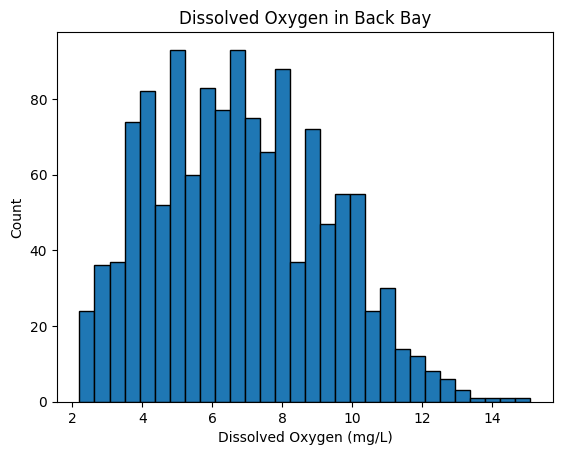

In [144]:
plt.figure()
plt.hist(df["Dissolved_Oxygen"], bins=30, edgecolor="k")
plt.xlabel("Dissolved Oxygen (mg/L)")
plt.ylabel("Count")
plt.title("Dissolved Oxygen in Back Bay")
plt.show()

In [145]:
columns_numeric = [
    "Salinity", "Dissolved_Oxygen", "pH", "Secchi_Depth", "Water_Depth", "Water_Temp", "Air_Temp"
]

df[columns_numeric].corr()

# correlation matrix of numeric columns

,Salinity,Dissolved_Oxygen,pH,Secchi_Depth,Water_Depth,Water_Temp,Air_Temp
Salinity,1.000000,0.383110,0.332852,-0.151247,-0.067589,0.007107,0.082413
Dissolved_Oxygen,0.383110,1.000000,0.081691,-0.067972,-0.020483,-0.537437,-0.331970
pH,0.332852,0.081691,1.000000,-0.119537,-0.134210,0.203094,0.171786
Secchi_Depth,-0.151247,-0.067972,-0.119537,1.000000,0.850850,0.019247,-0.017984
Water_Depth,-0.067589,-0.020483,-0.134210,0.850850,1.000000,0.069976,0.049967
Water_Temp,0.007107,-0.537437,0.203094,0.019247,0.069976,1.000000,0.698497
Air_Temp,0.082413,-0.331970,0.171786,-0.017984,0.049967,0.698497,1.000000


In [146]:
train, test = train_test_split(df, test_size=0.3, random_state=1)

print(train.shape)
test.shape

(914, 8)


(393, 8)

In [147]:
formula = "Dissolved_Oxygen ~ Salinity + pH + np.log(Water_Temp) + C(Site_Id)"
log_water = smf.ols(formula=formula, data=train).fit()

In [148]:
resid = log_water.resid
fitted = log_water.fittedvalues

In [149]:
# shapiro-wilk test, normality

W, p_value = shapiro(resid)
print("W = ", W)
print("p-value = ", p_value)

W =  0.9968658571701243
p-value =  0.06953926199462288


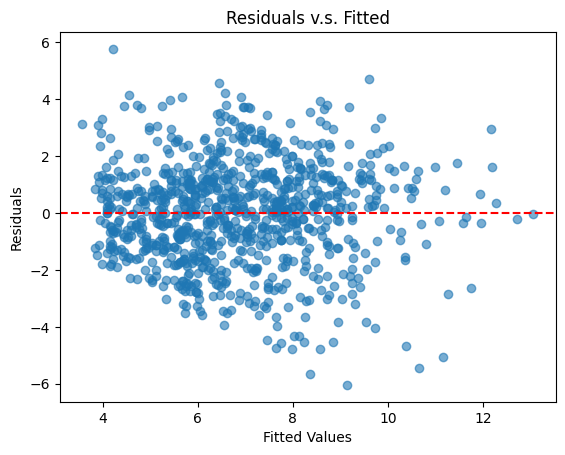

In [150]:
# residual vs fitted plot

plt.figure()
plt.scatter(fitted, resid, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.title("Residuals v.s. Fitted")
plt.show()

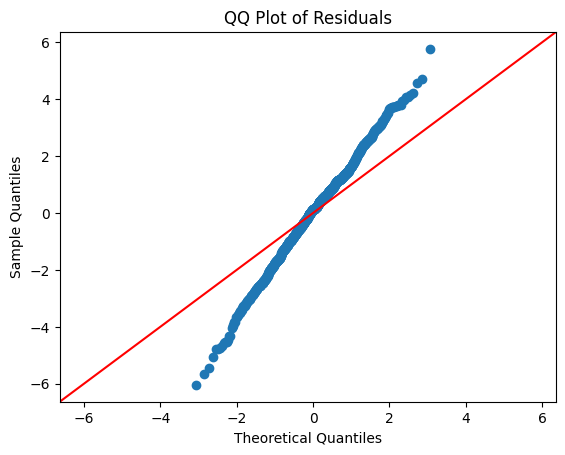

In [151]:
# qq plot of residuals

sm.qqplot(resid, line="45")
plt.title("QQ Plot of Residuals")
plt.show()

In [ ]:
# mean absolute error

pred_train = log_water.predict(train)
pred_test = log_water.predict(test)

mae_train = mean_absolute_error(train["Dissolved_Oxygen"], pred_train)
mae_test = mean_absolute_error(test["Dissolved_Oxygen"], pred_test)

print("MAE Train:", mae_train)
print("MAE Test:", mae_test)

1.398897917906157
1.2842232378871186
